
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---
## Trabajo práctico entregable - Parte 1

## Grupo 22
### Matias Alessandro Ruiz
### Javier Norberto Zader
### Maria Belen Aguilar Velasquez

In [24]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [ ]:
df[:10]

,Unnamed: 0,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,...,salir_o_seguir_contestando_sobre_las_guardias,work_on_call_duty,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,profile_age,profile_gender,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.00,5800000.00,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.00
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.00,10200000.00,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,Terminar encuesta,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.00
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.00,3137662.00,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.00
3,3,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),1606000.00,1360000.00,Cobro parte del salario en dólares,1004,No,No recibo bono,...,NaN,NaN,NaN,NaN,25,Hombre Cis,Sí,True,Semi-Senior,1606000.00
4,4,Córdoba,Full-Time,Tercerizado (trabajo a través de consultora o ...,1325301.00,NaN,Cobro parte del salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,22,Hombre Cis,Sí,True,Senior,1325301.00
5,5,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),2670205.00,2167989.00,Cobro parte del salario en dólares,986,No,No recibo bono,...,Terminar encuesta,No,0.0,Porcentaje de mi sueldo bruto,48,Hombre Cis,Sí,True,Senior,2670205.00
6,6,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),4000000.00,4000000.00,Cobro todo el salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,No,0.0,Bruto,50,Hombre Cis,Sí,True,Senior,4000000.00
7,7,Córdoba,Full-Time,Staff (planta permanente),4200000.00,3600000.00,Cobro parte del salario en dólares,1070,No,No recibo bono,...,Responder sobre guardias,"Sí, pasiva",0.0,Porcentaje de mi sueldo bruto,43,Hombre Cis,Sí,True,Senior,4200000.00
8,8,Buenos Aires,Full-Time,Freelance,3000000.00,2000000.00,Mi sueldo está dolarizado (pero cobro en moned...,1150,No,No recibo bono,...,NaN,NaN,NaN,NaN,41,Hombre Cis,No,True,Senior,3000000.00
9,9,Buenos Aires,Full-Time,Staff (planta permanente),3953142.06,3258576.49,Mi sueldo está dolarizado (pero cobro en moned...,NaN,Un sueldo,Performance de la compañía,...,NaN,NaN,NaN,NaN,47,Hombre Cis,Sí,True,Senior,3953142.06


# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

In [3]:
# Columnas relevantes para el análisis lenguaje-salario
# work_dedication: para filtrar solo Full-Time (si no, part-time contamina)
# work_seniority: variable de control (un senior de PHP gana más que un junior de Rust)
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO', 'work_dedication', 'work_seniority']

### Limpieza de datos

Filtramos filas con salario NaN, solo Full-Time, y eliminamos valores absurdos + outliers por IQR.
Esto reformula la pregunta a: *¿Cuáles son los lenguajes asociados a mejores salarios entre trabajadores full-time?*

In [4]:
# Limpieza del dataset
df_clean = df[relevant_columns].copy()
print(f"Filas iniciales: {len(df_clean)}")

# Eliminar filas sin salario o sin lenguaje
df_clean = df_clean.dropna(subset=["salary_monthly_NETO"])
df_clean = df_clean.dropna(subset=["tools_programming_languages"])
print(f"Después de eliminar NaN: {len(df_clean)}")

# Solo Full-Time (part-time cobra menos por definición, no por lenguaje)
df_clean = df_clean[df_clean["work_dedication"] == "Full-Time"]
print(f"Solo Full-Time: {len(df_clean)}")

# Eliminar errores obvios por dominio
salary_min, salary_max = 300_000, 20_000_000
df_clean = df_clean[
    (df_clean["salary_monthly_NETO"] >= salary_min)
    & (df_clean["salary_monthly_NETO"] <= salary_max)
]
print(f"Salarios [{salary_min:,} - {salary_max:,}]: {len(df_clean)}")

# Eliminar outliers por IQR
Q1 = df_clean["salary_monthly_NETO"].quantile(0.25)
Q3 = df_clean["salary_monthly_NETO"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df_clean[
    (df_clean["salary_monthly_NETO"] >= lower_bound)
    & (df_clean["salary_monthly_NETO"] <= upper_bound)
]
print(f"Después de IQR [{lower_bound:,.0f} - {upper_bound:,.0f}]: {len(df_clean)}")
print(f"\nFilas eliminadas: {len(df) - len(df_clean)} ({(len(df) - len(df_clean)) / len(df) * 100:.1f}%)")
df_clean["salary_monthly_NETO"].describe()

Filas iniciales: 4939
Después de eliminar NaN: 4716
Solo Full-Time: 4515
Salarios [300,000 - 20,000,000]: 4467
Después de IQR [-1,190,074 - 7,114,044]: 4243

Filas eliminadas: 696 (14.1%)


,salary_monthly_NETO
count,4.243000e+03
mean,2.971711e+06
std,1.443912e+06
min,3.000000e+05
25%,1.900000e+06
50%,2.700000e+06
75%,3.826043e+06
max,7.100000e+06


### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [5]:
df.tools_programming_languages[:3]

,tools_programming_languages
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL"
1,".NET, C#, HTML, Javascript, SQL"
2,"Go, SQL"


Las siguientes celdas de código separan estos lenguajes de programación y cuentan la frecuencia con la que aparecen.

No es necesario entender este código en profundidad, aunque sí es un buen ejercicio.

In [6]:
# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')
  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df.loc[:, 'cured_programming_languages'] = df.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,work_dedication,work_seniority,cured_programming_languages
0,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,"[.net, c#, css, go, html, java, javascript, sql]"


En la columna `programming_language` se encuentra cada lenguaje por separado. Notar que si una respuesta contenía 3 lenguajes, como `"HTML, Javascript, Python"`, la fila ha sido replicada 3 veces. Por ello, hay tres filas con índice 1.

In [7]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:10]

,frequency,count
0,sql,2217
1,javascript,1860
2,python,1774
3,html,1385
4,typescript,1136
5,css,885
6,bash/shell,881
7,java,787
8,php,566
9,.net,530


## Filtrado de lenguajes relevantes

El siguiente código permite seleccionar sólo las filas donde el valor de la columna `programming_language` se encuentre en la lista `interesting_languages`.

In [8]:
# Explode limpio sobre df_clean (ya filtrado: Full-Time, sin outliers)
df_clean = df_clean.copy()
df_clean["lang_list"] = (
    df_clean["tools_programming_languages"]
    .str.split(",")
    .apply(lambda langs: [l.strip() for l in langs])
)
df_analysis = df_clean.explode("lang_list").rename(columns={"lang_list": "language"})

# Lenguajes con >= 100 respuestas (umbral para estadísticas estables)
lang_counts = df_analysis["language"].value_counts()
MIN_RESPONSES = 100
popular_languages = lang_counts[lang_counts >= MIN_RESPONSES].index.tolist()

# Filtrar y sacar "Ninguno de los anteriores"
df_analysis = df_analysis[df_analysis["language"].isin(popular_languages)]
df_analysis = df_analysis[df_analysis["language"] != "Ninguno de los anteriores"]
popular_languages = [l for l in popular_languages if l != "Ninguno de los anteriores"]

print(f"Lenguajes seleccionados ({len(popular_languages)}):")
for lang in popular_languages:
    print(f"  {lang}: {lang_counts[lang]} respuestas")
print(f"\nFilas en dataset de análisis: {len(df_analysis)}")

Lenguajes seleccionados (15):
  SQL: 1917 respuestas
  Javascript: 1578 respuestas
  Python: 1496 respuestas
  HTML: 1183 respuestas
  TypeScript: 942 respuestas
  Bash/Shell: 750 respuestas
  CSS: 748 respuestas
  Java: 690 respuestas
  PHP: 479 respuestas
  .NET: 475 respuestas
  C#: 383 respuestas
  Go: 217 respuestas
  VBA: 116 respuestas
  Kotlin: 113 respuestas
  C++: 105 respuestas

Filas en dataset de análisis: 11192


### Opción A — Comparación de distribuciones

Usamos boxplot, violinplot y KDE para comparar la forma de la distribución salarial por lenguaje. El boxplot muestra medianas y dispersión; el violinplot revela la forma (bimodalidad, concentración); el KDE permite superponer curvas para comparación directa.

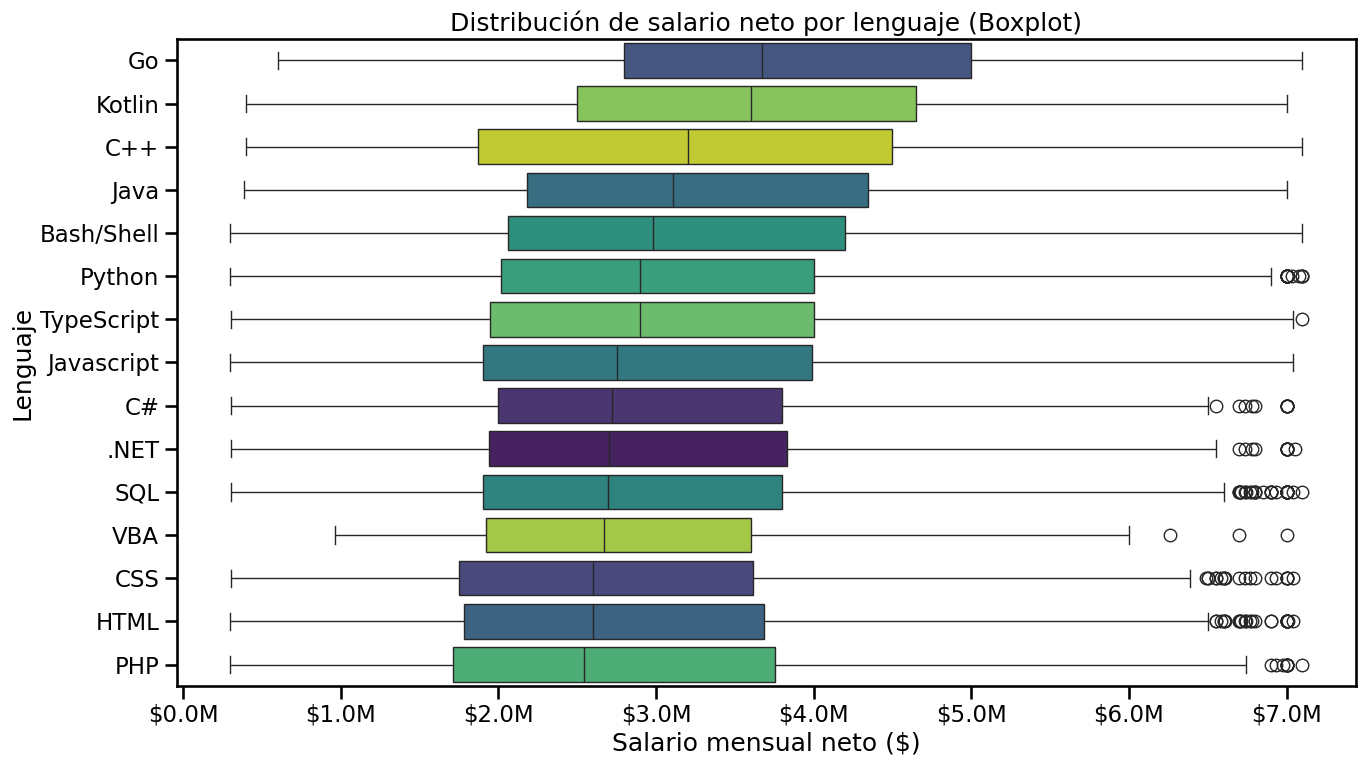

In [25]:
# Orden por mediana para todos los gráficos
median_order = (
    df_analysis.groupby("language")["salary_monthly_NETO"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# A1: Boxplot — muestra mediana, IQR y outliers por lenguaje
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(
    data=df_analysis, x="salary_monthly_NETO", y="language",
    order=median_order,
    hue="language",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Distribución de salario neto por lenguaje (Boxplot)")
ax.set_xlabel("Salario mensual neto ($)")
ax.set_ylabel("Lenguaje")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

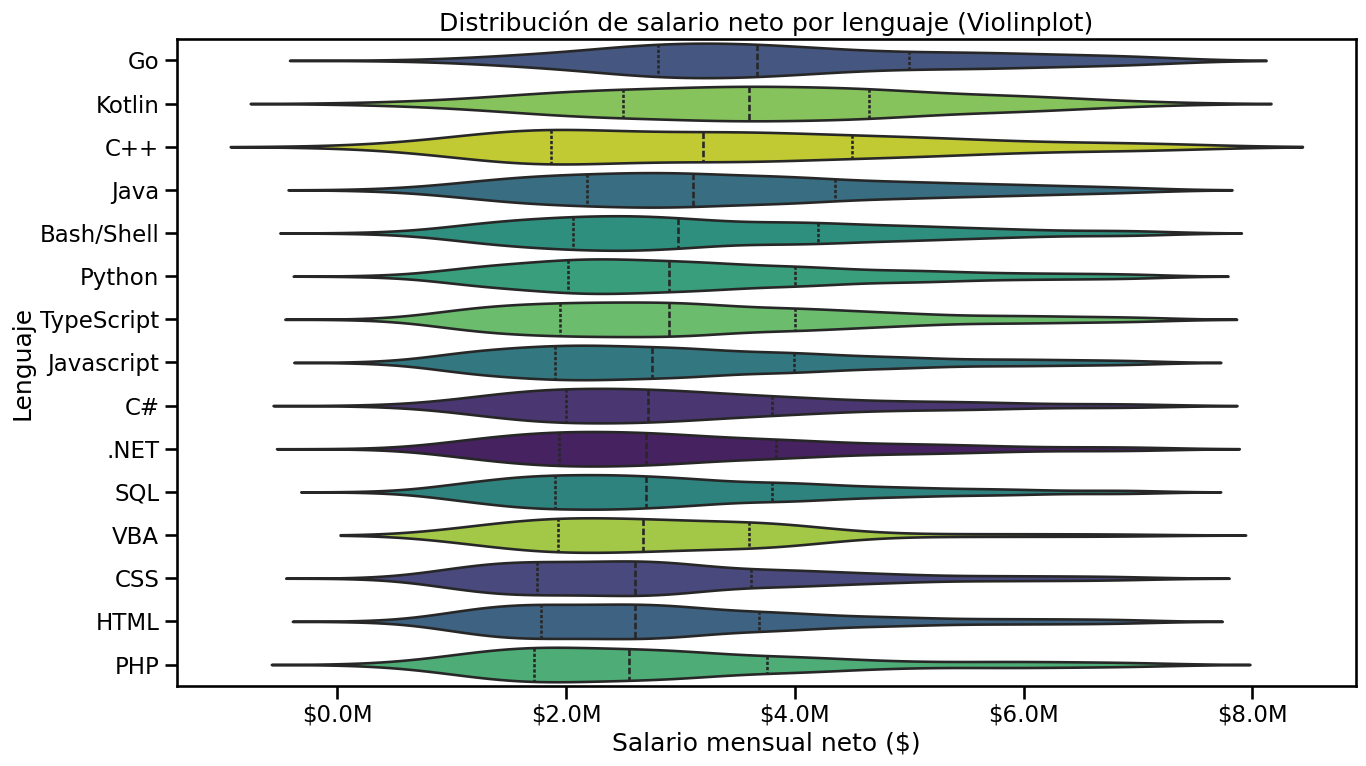

In [26]:
# A2: Violinplot — muestra la forma completa de la distribución
fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(
    data=df_analysis, x="salary_monthly_NETO", y="language",
    order=median_order,
    hue="language",
    palette="viridis",
    legend=False,
    density_norm="width", inner="quartile", ax=ax,
)
ax.set_title("Distribución de salario neto por lenguaje (Violinplot)")
ax.set_xlabel("Salario mensual neto ($)")
ax.set_ylabel("Lenguaje")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

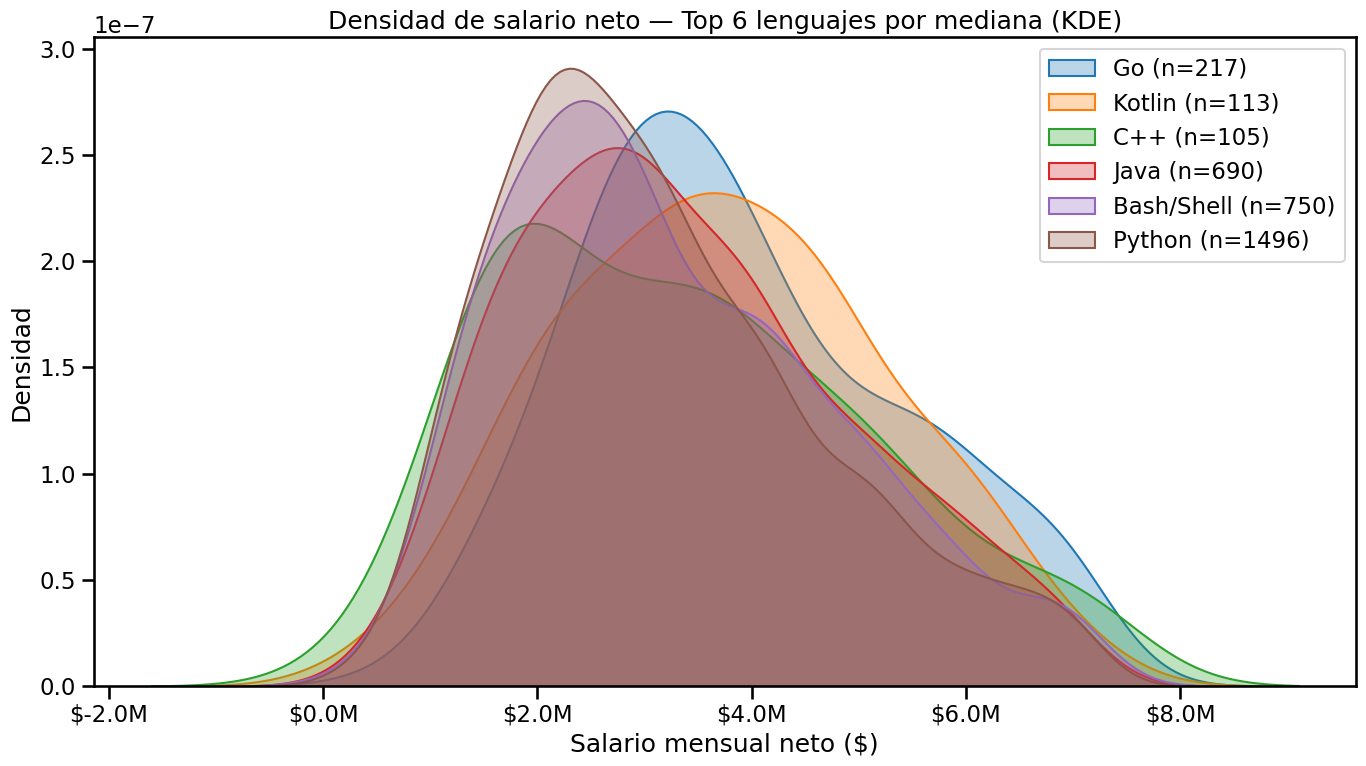

In [11]:
# A3: KDE superpuesto — top 6 para legibilidad
top_6 = median_order[:6]
fig, ax = plt.subplots(figsize=(14, 8))
for lang in top_6:
    data = df_analysis[df_analysis["language"] == lang]["salary_monthly_NETO"]
    sns.kdeplot(data, label=f"{lang} (n={len(data)})", ax=ax, fill=True, alpha=0.3)
ax.set_title("Densidad de salario neto — Top 6 lenguajes por mediana (KDE)")
ax.set_xlabel("Salario mensual neto ($)")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

### Opción B — Estadística descriptiva

Tabla con count, media, mediana, std, Q1, Q3, P90 y skewness por lenguaje. Además: porcentaje de cada lenguaje presente en el top 10% global de salarios.

In [12]:
# Estadísticas descriptivas por lenguaje
salary_stats_full = (
    df_analysis.groupby("language")["salary_monthly_NETO"]
    .agg(
        count="count", mean="mean", median="median", std="std",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        skew="skew",
    )
    .sort_values("median", ascending=False)
)
salary_stats_full["CV"] = salary_stats_full["std"] / salary_stats_full["mean"]
salary_stats_full.round(0)

,count,mean,median,std,Q1,Q3,P90,skew,CV
language,,,,,,,,,
Go,217,3892806.0,3672182.0,1495168.0,2800000.0,5000000.0,6000000.0,0.0,0.0
Kotlin,113,3724758.0,3600000.0,1496393.0,2500000.0,4650000.0,5892200.0,0.0,0.0
C++,105,3355585.0,3200000.0,1696319.0,1870000.0,4500000.0,5840000.0,1.0,1.0
Java,690,3360127.0,3109000.0,1518213.0,2180328.0,4347500.0,5600000.0,0.0,0.0
Bash/Shell,750,3232731.0,2980000.0,1510855.0,2062500.0,4200000.0,5500000.0,1.0,0.0
Python,1496,3136053.0,2900000.0,1482130.0,2019218.0,4000000.0,5300000.0,1.0,0.0
TypeScript,942,3116027.0,2900000.0,1499338.0,1950000.0,4000000.0,5200000.0,1.0,0.0
Javascript,1578,3012730.0,2750000.0,1486777.0,1900000.0,3991462.0,5100000.0,1.0,0.0
C#,383,3021683.0,2719000.0,1421513.0,2000000.0,3800000.0,5092364.0,1.0,0.0


Percentil 90 global: $5,200,000


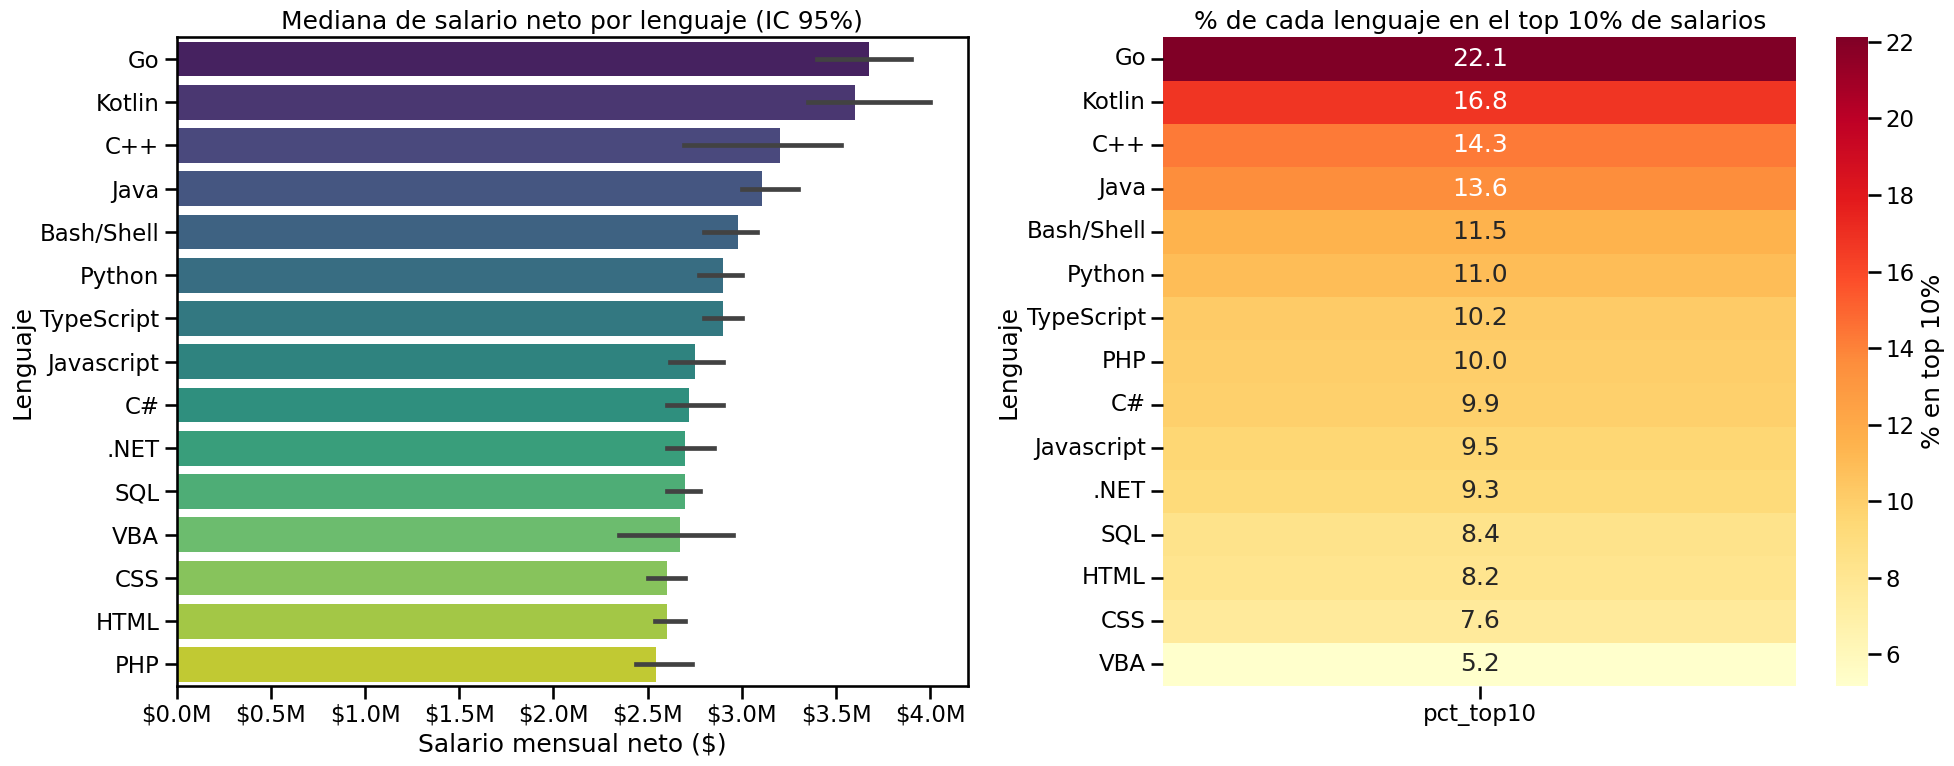

In [27]:
# ¿Quiénes dominan el top 10% de salarios?
p90_global = df_analysis["salary_monthly_NETO"].quantile(0.90)
print(f"Percentil 90 global: ${p90_global:,.0f}")

top_earners = (
    df_analysis.groupby("language")["salary_monthly_NETO"]
    .apply(lambda x: (x >= p90_global).mean() * 100)
    .sort_values(ascending=False)
)

# Barplot de medianas con intervalo de confianza 95%
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(
    data=df_analysis, x="salary_monthly_NETO", y="language",
    order=median_order, estimator=np.median, errorbar=("ci", 95),
    hue="language", hue_order=median_order,
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Mediana de salario neto por lenguaje (IC 95%)")
axes[0].set_xlabel("Salario mensual neto ($)")
axes[0].set_ylabel("Lenguaje")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

# Heatmap del % en top 10%
top_earners_df = top_earners.reset_index()
top_earners_df.columns = ["language", "pct_top10"]
top_earners_df = top_earners_df.set_index("language")
sns.heatmap(
    top_earners_df, annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "% en top 10%"}, ax=axes[1],
)
axes[1].set_title("% de cada lenguaje en el top 10% de salarios")
axes[1].set_ylabel("Lenguaje")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

### Opción C — Probabilidades condicionales

P(salario >= X | sabe lenguaje L): para cada lenguaje y umbral, calculamos la probabilidad de superar ese salario. El "lift" indica cuánto más (o menos) probable es respecto al promedio general.

In [14]:
# Probabilidades condicionales por lenguaje y umbral
thresholds = [2_000_000, 3_000_000, 4_000_000, 5_000_000]

# Probabilidad base
print("Probabilidad BASE (todos los full-time):")
for t in thresholds:
    p_base = (df_analysis["salary_monthly_NETO"] >= t).mean() * 100
    print(f"  P(salario >= ${t/1e6:.0f}M) = {p_base:.1f}%")

# Por lenguaje
prob_by_lang = {}
for lang in median_order:
    data = df_analysis[df_analysis["language"] == lang]["salary_monthly_NETO"]
    probs = {}
    for t in thresholds:
        key = f">={int(t // 1_000_000)}M"
        probs[key] = (data >= t).mean() * 100
    prob_by_lang[lang] = probs

prob_df = pd.DataFrame(prob_by_lang).T
print("\nProbabilidad de ganar >= X por lenguaje (%):")
print(prob_df.round(1).to_string())

# Lift vs promedio general
print("\nLIFT vs promedio general (top 6 lenguajes):")
for t in thresholds:
    key = f">={int(t // 1_000_000)}M"
    p_base = (df_analysis["salary_monthly_NETO"] >= t).mean() * 100
    print(f"\n  Umbral ${int(t // 1_000_000)}M (base: {p_base:.1f}%):")
    for lang in median_order[:6]:
        p_lang = prob_by_lang[lang][key]
        if p_base > 0:
            lift = (p_lang / p_base - 1) * 100
            direction = "+" if lift > 0 else ""
            print(f"    {lang:15s}: {p_lang:5.1f}% ({direction}{lift:.0f}% vs promedio)")

Probabilidad BASE (todos los full-time):
  P(salario >= $2M) = 73.8%
  P(salario >= $3M) = 45.8%
  P(salario >= $4M) = 25.3%
  P(salario >= $5M) = 12.8%

Probabilidad de ganar >= X por lenguaje (%):
            >=2M  >=3M  >=4M  >=5M
Go          91.7  71.4  41.9  26.3
Kotlin      87.6  68.1  43.4  22.1
C++         69.5  55.2  33.3  21.0
Java        79.9  55.7  32.2  18.1
Bash/Shell  77.6  49.7  31.6  16.4
Python      76.9  48.3  26.9  14.2
TypeScript  74.6  48.4  27.1  12.8
Javascript  72.4  45.1  24.8  11.9
C#          75.7  43.6  23.0  11.7
.NET        73.9  42.9  23.6  12.0
SQL         72.4  42.8  22.7  10.7
VBA         72.4  39.7  15.5   5.2
CSS         68.3  38.0  20.2   9.0
HTML        69.1  40.2  20.4  10.1
PHP         67.6  39.9  21.7  11.3

LIFT vs promedio general (top 6 lenguajes):

  Umbral $2M (base: 73.8%):
    Go             :  91.7% (+24% vs promedio)
    Kotlin         :  87.6% (+19% vs promedio)
    C++            :  69.5% (-6% vs promedio)
    Java           :  79.9%

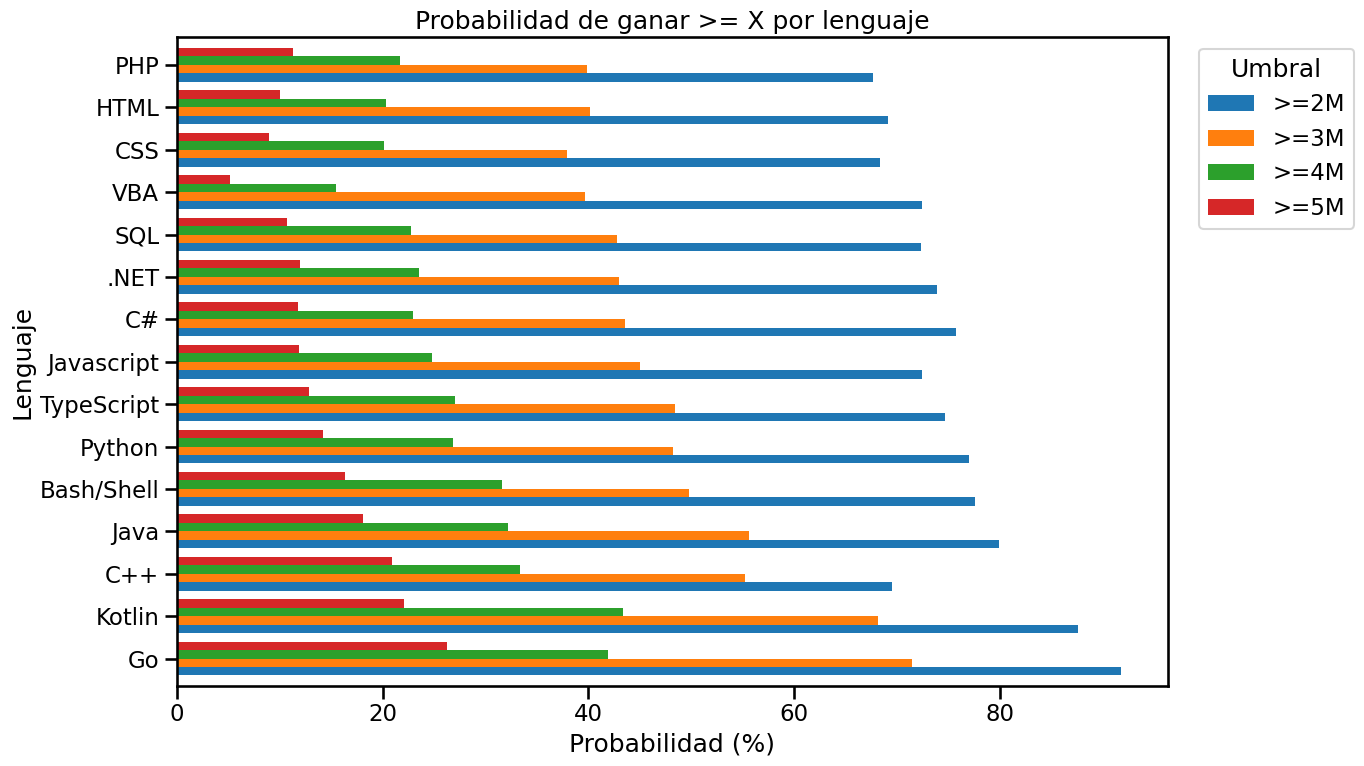

In [15]:
# Gráfico de probabilidades agrupadas
fig, ax = plt.subplots(figsize=(14, 8))
prob_plot = prob_df.loc[median_order]
prob_plot.plot(kind="barh", ax=ax, width=0.8)
ax.set_title("Probabilidad de ganar >= X por lenguaje")
ax.set_xlabel("Probabilidad (%)")
ax.set_ylabel("Lenguaje")
ax.legend(title="Umbral", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

In [16]:
# Dataset para Ejercicio 2 — limpieza básica (sin filtrar por Full-Time ni lenguaje)
df2 = df.copy()
df2 = df2.dropna(subset=["salary_monthly_NETO", "salary_monthly_BRUTO"])
df2 = df2[
    (df2["salary_monthly_NETO"] >= 300_000) & (df2["salary_monthly_NETO"] <= 20_000_000)
    & (df2["salary_monthly_BRUTO"] >= 300_000) & (df2["salary_monthly_BRUTO"] <= 20_000_000)
]
df2 = df2[(df2["profile_age"] >= 18) & (df2["profile_age"] <= 70)]

# Variables seleccionadas
num_vars = ["salary_monthly_NETO", "salary_monthly_BRUTO", "profile_age"]
cat_vars = ["work_seniority", "profile_gender"]

print(f"Dataset Ej2: {len(df2)} filas")
print(f"\nVariables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
for col in cat_vars:
    print(f"\n{col}:")
    print(df2[col].value_counts())

Dataset Ej2: 4653 filas

Variables numéricas: ['salary_monthly_NETO', 'salary_monthly_BRUTO', 'profile_age']
Variables categóricas: ['work_seniority', 'profile_gender']

work_seniority:
work_seniority
Senior         2708
Semi-Senior    1439
Junior          506
Name: count, dtype: int64

profile_gender:
profile_gender
Hombre Cis           3641
Mujer Cis             924
Prefiero no decir      49
No binarie             20
Queer                   9
Trans                   8
Agénero                 1
Name: count, dtype: int64


## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




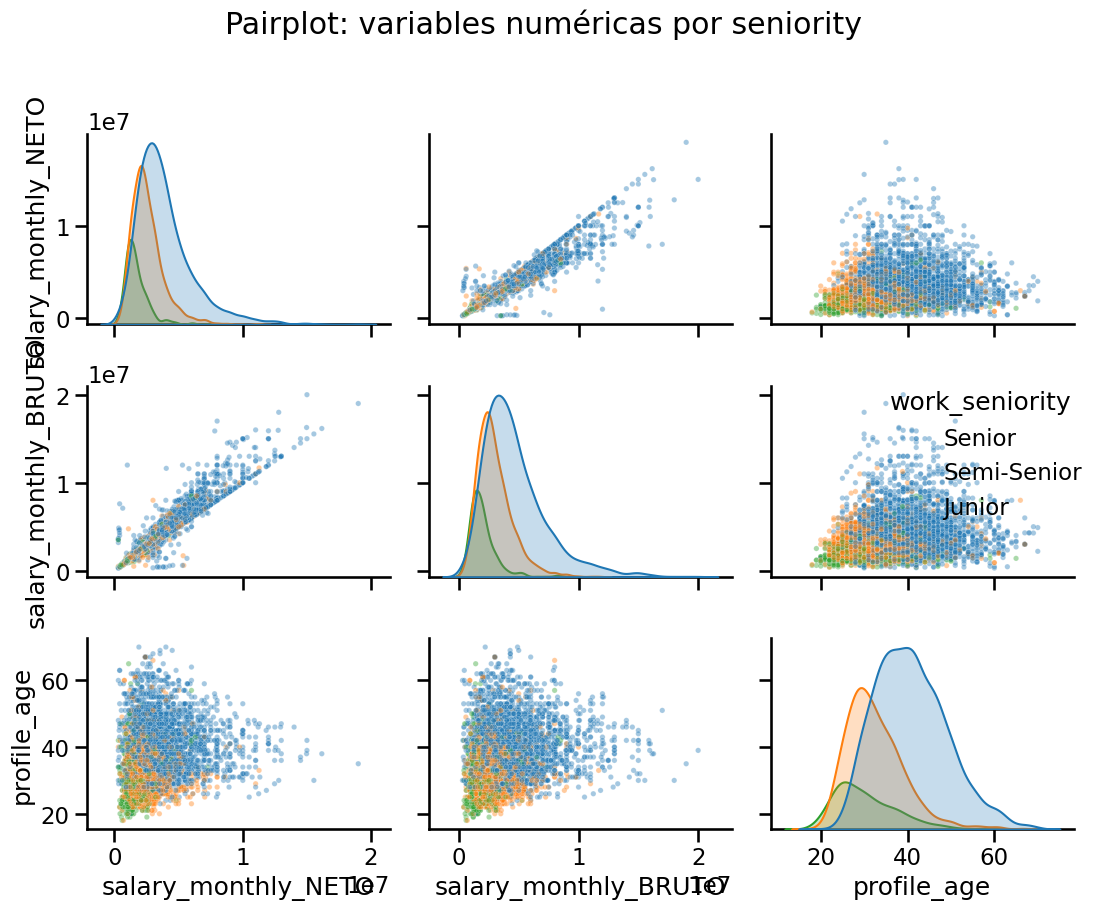

In [17]:
# 2a.1: Pairplot — cruza todas las numéricas, coloreado por seniority
g = sns.pairplot(
    df2[num_vars + ["work_seniority"]].dropna(),
    hue="work_seniority",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    height=3,
)
g.figure.suptitle("Pairplot: variables numéricas por seniority", y=1.02)
plt.tight_layout()
plt.show()

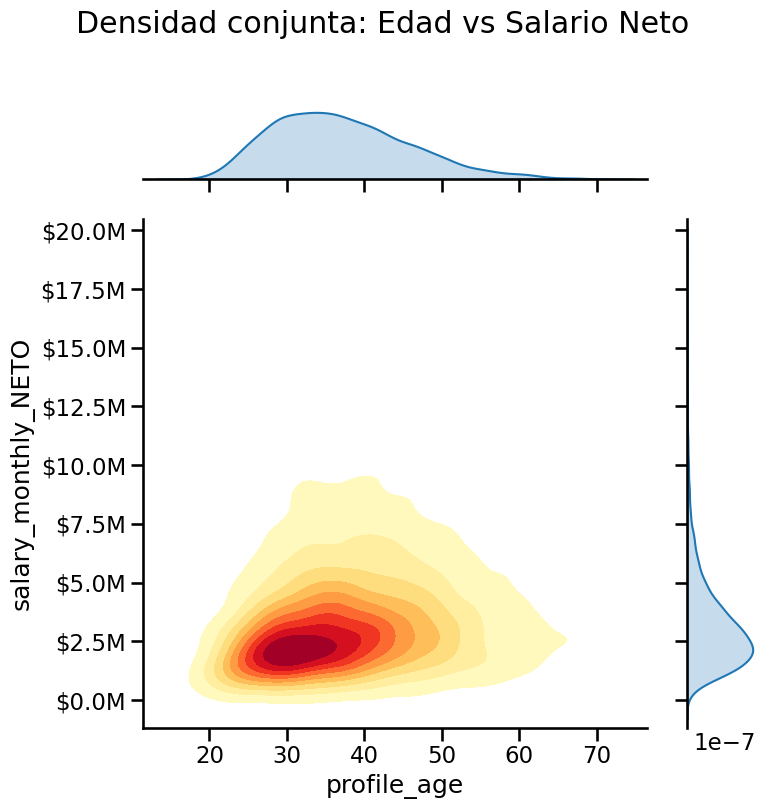

In [18]:
# 2a.2: Jointplot KDE — densidad conjunta edad vs salario neto
g = sns.jointplot(
    data=df2, x="profile_age", y="salary_monthly_NETO",
    kind="kde", fill=True, cmap="YlOrRd", height=8,
)
g.ax_joint.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
g.figure.suptitle("Densidad conjunta: Edad vs Salario Neto", y=1.02)
plt.tight_layout()
plt.show()

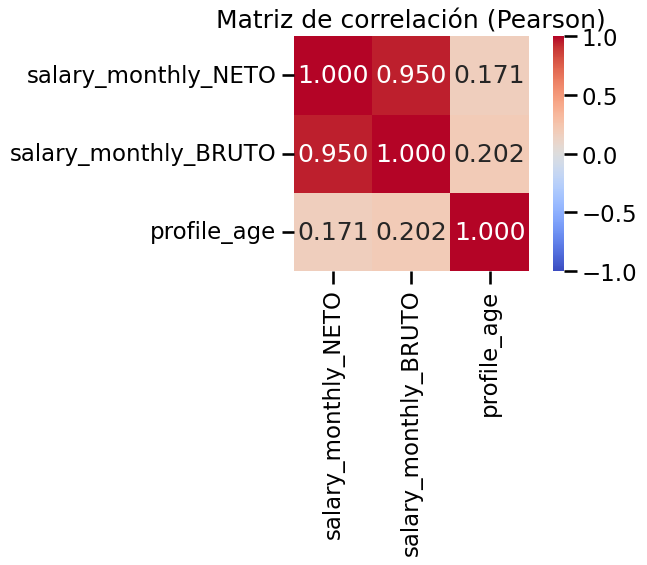

Correlación BRUTO-NETO: 0.950
Correlación Edad-Salario NETO: 0.171


In [19]:
# 2a.3: Heatmap de correlación de Pearson
corr_matrix = df2[num_vars].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, ax=ax,
)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

print(f"Correlación BRUTO-NETO: {corr_matrix.loc['salary_monthly_BRUTO', 'salary_monthly_NETO']:.3f}")
print(f"Correlación Edad-Salario NETO: {corr_matrix.loc['profile_age', 'salary_monthly_NETO']:.3f}")

## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



Pearson:  r = 0.9504, p = 0.00e+00, R² = 0.9033
Spearman: rho = 0.9578, p = 0.00e+00

El bruto explica el 90.3% de la varianza del neto.
CONCLUSIÓN: Con r~0.95, la columna de salario bruto es REDUNDANTE.


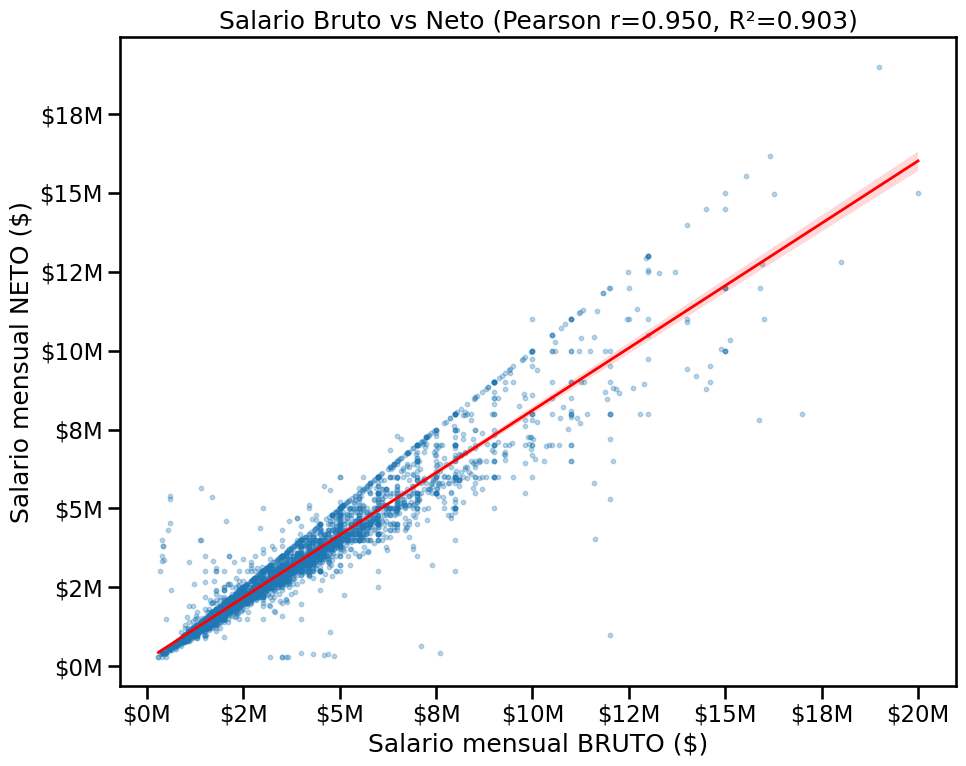

In [20]:
# 2b: Correlación Pearson y Spearman entre salario bruto y neto
r_pearson, p_pearson = stats.pearsonr(df2["salary_monthly_BRUTO"], df2["salary_monthly_NETO"])
r_spearman, p_spearman = stats.spearmanr(df2["salary_monthly_BRUTO"], df2["salary_monthly_NETO"])

print(f"Pearson:  r = {r_pearson:.4f}, p = {p_pearson:.2e}, R² = {r_pearson**2:.4f}")
print(f"Spearman: rho = {r_spearman:.4f}, p = {p_spearman:.2e}")
print(f"\nEl bruto explica el {r_pearson**2*100:.1f}% de la varianza del neto.")
print("CONCLUSIÓN: Con r~0.95, la columna de salario bruto es REDUNDANTE.")

# Scatter + regresión
fig, ax = plt.subplots(figsize=(10, 8))
sns.regplot(
    data=df2, x="salary_monthly_BRUTO", y="salary_monthly_NETO",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "red", "linewidth": 2}, ax=ax,
)
ax.set_title(f"Salario Bruto vs Neto (Pearson r={r_pearson:.3f}, R²={r_pearson**2:.3f})")
ax.set_xlabel("Salario mensual BRUTO ($)")
ax.set_ylabel("Salario mensual NETO ($)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
plt.tight_layout()
plt.show()

## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






Niveles de estudio:
profile_studies_level
Universitario               1116
Terciario                    257
Maestría                     104
Posgrado/Especialización     102
Secundario                    62
Doctorado                     26
Posdoctorado                   6
Name: count, dtype: int64

Subpoblaciones: ['Universitario', 'Terciario']

Métrica                     Universitario            Terciario
--------------------------------------------------------------
N (datos)                           1,116                  257
Media                           3,340,980            2,533,467
Mediana                         2,945,086            2,158,000
Std                             2,092,015            1,641,000
Q1                              1,900,000            1,500,000
Q3                              4,200,000            3,000,000
IQR                             2,300,000            1,500,000


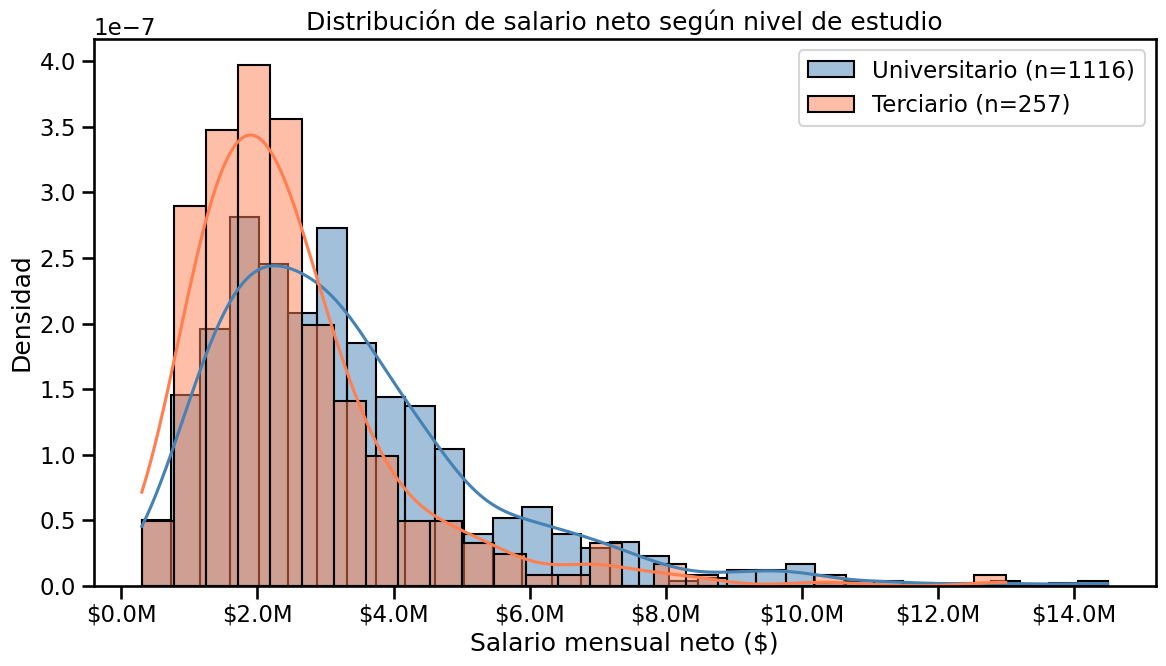


Test Mann-Whitney U: estadístico = 181,558, p-valor = 2.78e-11
→ Rechazamos H0: las distribuciones son DIFERENTES (p < 0.05)
→ El salario y el nivel de estudio NO son independientes.


In [21]:
# 2c: Densidad condicional — salario según nivel de estudio
print("Niveles de estudio:")
print(df2["profile_studies_level"].value_counts())

# Las dos subpoblaciones más numerosas
top_2_studies = df2["profile_studies_level"].value_counts().head(2).index.tolist()
print(f"\nSubpoblaciones: {top_2_studies}")

group_a = df2[df2["profile_studies_level"] == top_2_studies[0]]["salary_monthly_NETO"]
group_b = df2[df2["profile_studies_level"] == top_2_studies[1]]["salary_monthly_NETO"]

# Medidas de centralización y dispersión
print(f"\n{'Métrica':<20} {top_2_studies[0]:>20} {top_2_studies[1]:>20}")
print("-" * 62)
print(f"{'N (datos)':<20} {len(group_a):>20,} {len(group_b):>20,}")
print(f"{'Media':<20} {group_a.mean():>20,.0f} {group_b.mean():>20,.0f}")
print(f"{'Mediana':<20} {group_a.median():>20,.0f} {group_b.median():>20,.0f}")
print(f"{'Std':<20} {group_a.std():>20,.0f} {group_b.std():>20,.0f}")
print(f"{'Q1':<20} {group_a.quantile(0.25):>20,.0f} {group_b.quantile(0.25):>20,.0f}")
print(f"{'Q3':<20} {group_a.quantile(0.75):>20,.0f} {group_b.quantile(0.75):>20,.0f}")
print(f"{'IQR':<20} {group_a.quantile(0.75)-group_a.quantile(0.25):>20,.0f} {group_b.quantile(0.75)-group_b.quantile(0.25):>20,.0f}")

# Histogramas superpuestos normalizados
fig, ax = plt.subplots(figsize=(12, 7))
sns.histplot(group_a, label=f"{top_2_studies[0]} (n={len(group_a)})",
             stat="density", kde=True, alpha=0.5, color="steelblue", ax=ax)
sns.histplot(group_b, label=f"{top_2_studies[1]} (n={len(group_b)})",
             stat="density", kde=True, alpha=0.5, color="coral", ax=ax)
ax.set_title("Distribución de salario neto según nivel de estudio")
ax.set_xlabel("Salario mensual neto ($)")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

# Test Mann-Whitney U (no asume normalidad)
stat_u, p_mw = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
print(f"\nTest Mann-Whitney U: estadístico = {stat_u:,.0f}, p-valor = {p_mw:.2e}")
if p_mw < 0.05:
    print("→ Rechazamos H0: las distribuciones son DIFERENTES (p < 0.05)")
    print("→ El salario y el nivel de estudio NO son independientes.")
else:
    print("→ No hay evidencia suficiente de diferencia.")

## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)


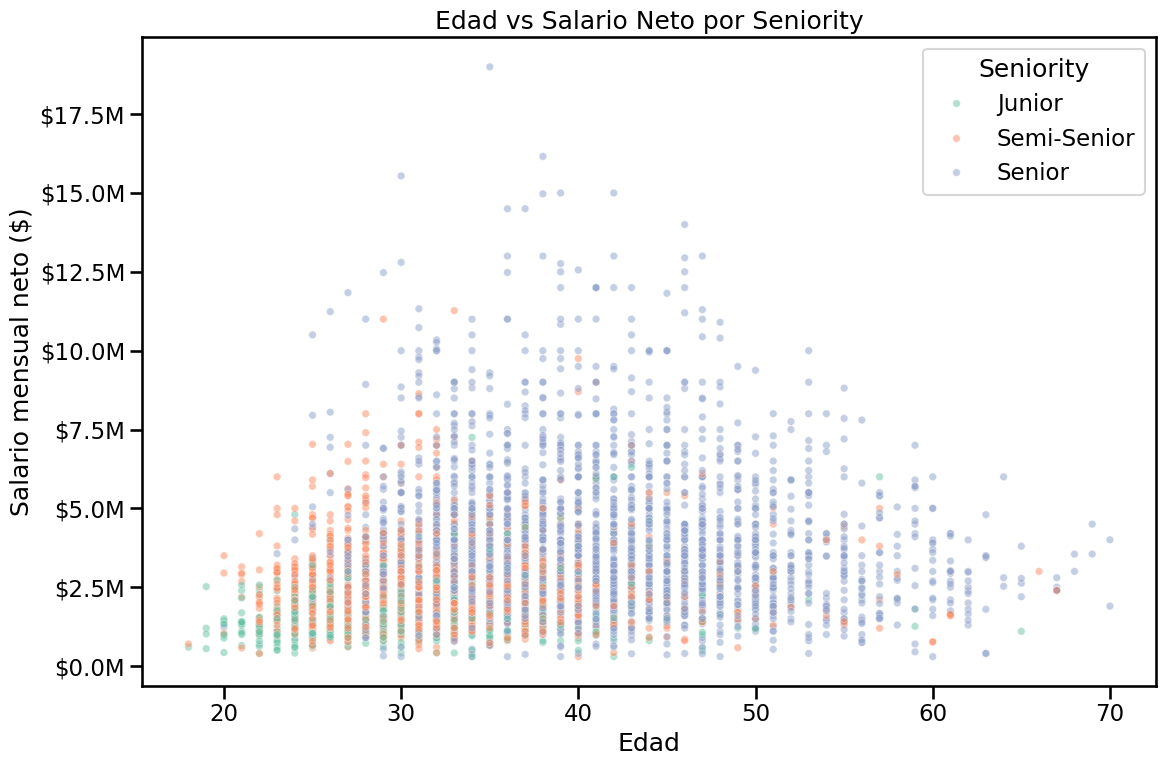

In [22]:
# 2d: Densidad conjunta condicional — edad vs salario, coloreado por seniority
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=df2, x="profile_age", y="salary_monthly_NETO",
    hue="work_seniority",
    hue_order=["Junior", "Semi-Senior", "Senior"],
    palette="Set2", alpha=0.5, s=30, ax=ax,
)
ax.set_title("Edad vs Salario Neto por Seniority")
ax.set_xlabel("Edad")
ax.set_ylabel("Salario mensual neto ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(title="Seniority")
plt.tight_layout()
plt.show()

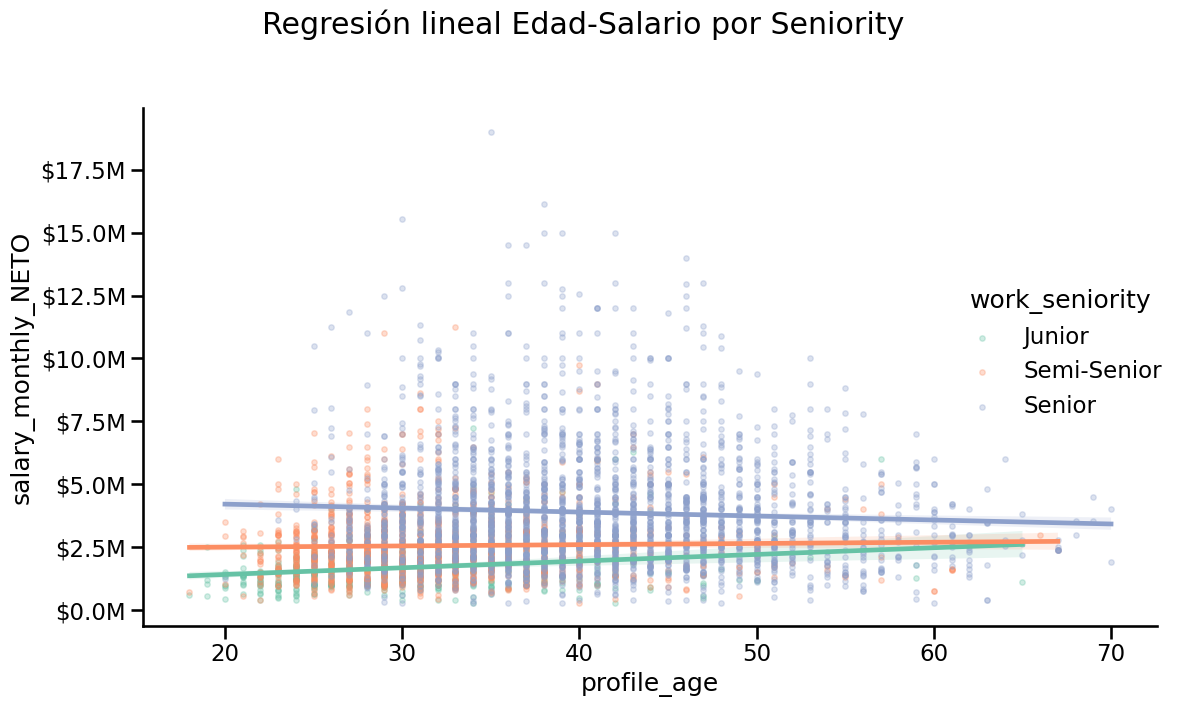

In [23]:
# 2d extra: lmplot — regresión lineal por seniority
g = sns.lmplot(
    data=df2, x="profile_age", y="salary_monthly_NETO",
    hue="work_seniority",
    hue_order=["Junior", "Semi-Senior", "Senior"],
    palette="Set2",
    scatter_kws={"alpha": 0.3, "s": 15},
    height=7, aspect=1.4,
)
g.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
g.figure.suptitle("Regresión lineal Edad-Salario por Seniority", y=1.02)
plt.tight_layout()
plt.show()